In [1]:
# Core libs
import os
import json
import time
import math
import random
import pathlib
from dataclasses import dataclass

# Numeric / data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import GTSRB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

# Progress bar
try:
    from tqdm.auto import tqdm
except ImportError:
    !pip -q install tqdm
    from tqdm.auto import tqdm

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
PROJECT_ROOT = pathlib.Path("/content/traffic-sign-classification")
REPORT_ROOT = PROJECT_ROOT / "reports" / "week4"
META_ROOT = PROJECT_ROOT / "artifacts" / "metadata"
DATA_ROOT = PROJECT_ROOT / "data"
CHECKPOINT_ROOT = pathlib.Path("/content/checkpoints")

for p in [DATA_ROOT, REPORT_ROOT, META_ROOT, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("REPORT_ROOT:", REPORT_ROOT)
print("CHECKPOINT_ROOT:", CHECKPOINT_ROOT)

PROJECT_ROOT: /content/traffic-sign-classification
REPORT_ROOT: /content/traffic-sign-classification/reports/week4
CHECKPOINT_ROOT: /content/checkpoints


In [4]:
tv_train = GTSRB(root=str(DATA_ROOT), split="train", download=True)
tv_test = GTSRB(root=str(DATA_ROOT), split="test", download=True)

print("Torchvision train size:", len(tv_train))
print("Torchvision test size:", len(tv_test))

100%|██████████| 187M/187M [00:09<00:00, 19.1MB/s]
100%|██████████| 89.0M/89.0M [00:06<00:00, 14.2MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 211kB/s]


Torchvision train size: 26640
Torchvision test size: 12630


In [6]:
train_df = pd.read_csv(META_ROOT / "train_metadata_full.csv")
test_df = pd.read_csv(META_ROOT / "test_metadata_full.csv")

with open(META_ROOT / "week2_pipeline_config.json", "r") as f:
    pipeline_config = json.load(f)

train_meta = train_df[train_df["split"] == "train"].reset_index(drop=True)
val_meta   = train_df[train_df["split"] == "val"].reset_index(drop=True)

print("Train rows:", len(train_meta))
print("Val rows:", len(val_meta))
print("Test rows:", len(test_df))
print(json.dumps(pipeline_config, indent=2))

Train rows: 23976
Val rows: 2664
Test rows: 12630
{
  "seed": 42,
  "image_size": 64,
  "batch_size": 128,
  "use_roi_crop": true,
  "preprocessing": "clahe",
  "pad_ratio": 0.08,
  "mean": [
    0.48077961802482605,
    0.4455212652683258,
    0.45868155360221863
  ],
  "std": [
    0.2539152204990387,
    0.2469169795513153,
    0.25597625970840454
  ]
}


In [7]:
import sys
sys.path.append(str(PROJECT_ROOT))

from src.datasets import GTSRBCustomDataset

NUM_CLASSES = 43
IMG_SIZE = int(pipeline_config["image_size"])
MEAN = pipeline_config["mean"]
STD = pipeline_config["std"]

USE_ROI_CROP = bool(pipeline_config["use_roi_crop"])
PREPROCESSING = pipeline_config["preprocessing"]
PAD_RATIO = float(pipeline_config["pad_ratio"])

BATCH_SIZE = 128
NUM_EPOCHS = 15
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 5

print("IMG_SIZE:", IMG_SIZE)
print("PREPROCESSING:", PREPROCESSING)

IMG_SIZE: 64
PREPROCESSING: clahe


In [8]:
# Train-time augmentation + normalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=10,
        translate=(0.10, 0.10),
        scale=(0.9, 1.1)
    ),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Eval-time (val/test) transform: no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# Datasets
train_ds = GTSRBCustomDataset(
    train_meta,
    transform=train_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

val_ds = GTSRBCustomDataset(
    val_meta,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

test_ds = GTSRBCustomDataset(
    test_df,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

print(len(train_ds), len(val_ds), len(test_ds))

23976 2664 12630


In [9]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

x, y = next(iter(train_loader))
print("x shape:", x.shape)
print("y shape:", y.shape)
print("label range:", int(y.min()), int(y.max()))

Train batches: 188
Val batches: 21
Test batches: 99
x shape: torch.Size([128, 3, 64, 64])
y shape: torch.Size([128])
label range: 1 42


In [10]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

print(model)
print("Output shape:", out.shape)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [12]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": float(acc),
        "precision_macro": float(precision),
        "recall_macro": float(recall),
        "f1_macro": float(f1)
    }

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_targets.extend(targets.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics

In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    for images, targets in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, targets)

        running_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(targets.cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_targets, all_preds)
    return epoch_loss, metrics, np.array(all_targets), np.array(all_preds)

In [15]:
def save_checkpoint(path, model, optimizer, epoch, history, best_score):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_score": best_score
    }, path)

In [16]:
history = []

best_val_f1 = -1.0
best_epoch = -1
patience_counter = 0

best_ckpt_path = CHECKPOINT_ROOT / "baseline_cnn_best.pth"
last_ckpt_path = CHECKPOINT_ROOT / "baseline_cnn_last.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
        model, val_loader, criterion, DEVICE
    )

    # ReduceLROnPlateau based on val F1
    scheduler.step(val_metrics["f1_macro"])

    epoch_time = time.time() - start_time
    lr_now = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "lr": lr_now,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_metrics["accuracy"],
        "train_precision_macro": train_metrics["precision_macro"],
        "train_recall_macro": train_metrics["recall_macro"],
        "train_f1_macro": train_metrics["f1_macro"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision_macro": val_metrics["precision_macro"],
        "val_recall_macro": val_metrics["recall_macro"],
        "val_f1_macro": val_metrics["f1_macro"],
        "epoch_time_sec": epoch_time
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"train_acc={train_metrics['accuracy']:.4f} | val_acc={val_metrics['accuracy']:.4f} | "
        f"val_f1={val_metrics['f1_macro']:.4f} | lr={lr_now:.6f}"
    )

    # Save "last" checkpoint every epoch
    save_checkpoint(last_ckpt_path, model, optimizer, epoch, history, best_val_f1)

    # Save best checkpoint based on val F1
    if val_metrics["f1_macro"] > best_val_f1:
        best_val_f1 = val_metrics["f1_macro"]
        best_epoch = epoch
        patience_counter = 0
        save_checkpoint(best_ckpt_path, model, optimizer, epoch, history, best_val_f1)
        print(f"Saved new best checkpoint at epoch {epoch}.")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 01/15 | train_loss=2.2279 | val_loss=1.4086 | train_acc=0.3357 | val_acc=0.5443 | val_f1=0.3306 | lr=0.001000
Saved new best checkpoint at epoch 1.


  0%|          | 0/188 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

...

Epoch 14/15 | train_loss=0.0505 | val_loss=0.0205 | train_acc=0.9839 | val_acc=0.9940 | val_f1=0.9920 | lr=0.000500
Saved new best checkpoint at epoch 14.


  0%|          | 0/188 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eefaa097240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eefaa097240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

  0%|          | 0/21 [00:00<?, ?it/s]

Epoch 15/15 | train_loss=0.0533 | val_loss=0.0267 | train_acc=0.9835 | val_acc=0.9925 | val_f1=0.9927 | lr=0.000500
Saved new best checkpoint at epoch 15.


In [17]:
history_df = pd.DataFrame(history)
history_csv_path = REPORT_ROOT / "baseline_history.csv"
history_df.to_csv(history_csv_path, index=False)

print(history_df.tail())
print("Saved:", history_csv_path)

    epoch      lr  train_loss  val_loss  train_accuracy  \
10     11  0.0005    0.095323  0.147628        0.971513   
11     12  0.0005    0.058447  0.027292        0.982024   
12     13  0.0005    0.059514  0.031000        0.981732   
13     14  0.0005    0.050497  0.020458        0.983859   
14     15  0.0005    0.053344  0.026728        0.983483   

    train_precision_macro  train_recall_macro  train_f1_macro  val_accuracy  \
10               0.963790            0.961181        0.962431      0.958333   
11               0.978250            0.975959        0.977083      0.989865   
12               0.976434            0.975850        0.976120      0.990616   
13               0.980793            0.979170        0.979923      0.993994   
14               0.980461            0.977548        0.978962      0.992492   

    val_precision_macro  val_recall_macro  val_f1_macro  epoch_time_sec  
10             0.958778          0.935227      0.941247       66.634303  
11             0.99287

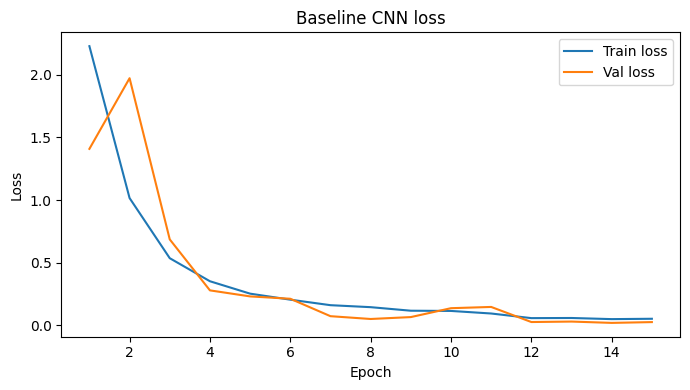

Saved: /content/traffic-sign-classification/reports/week4/baseline_loss_curve.png


In [18]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN loss")
plt.legend()
plt.tight_layout()

loss_plot_path = REPORT_ROOT / "baseline_loss_curve.png"
plt.savefig(loss_plot_path, dpi=200)
plt.show()

print("Saved:", loss_plot_path)

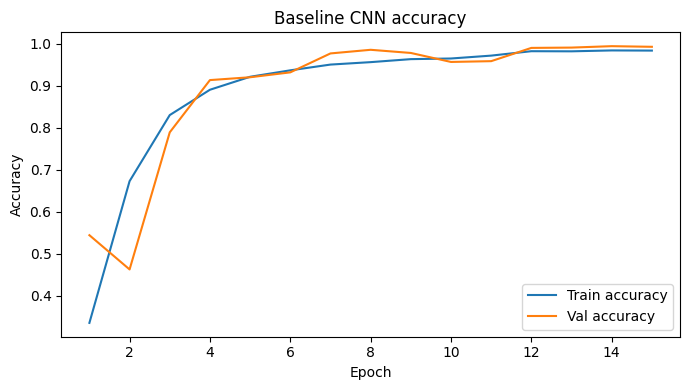

Saved: /content/traffic-sign-classification/reports/week4/baseline_accuracy_curve.png


In [19]:
plt.figure(figsize=(7, 4))
plt.plot(history_df["epoch"], history_df["train_accuracy"], label="Train accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], label="Val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN accuracy")
plt.legend()
plt.tight_layout()

acc_plot_path = REPORT_ROOT / "baseline_accuracy_curve.png"
plt.savefig(acc_plot_path, dpi=200)
plt.show()

print("Saved:", acc_plot_path)

In [20]:
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

print("Loaded best checkpoint from epoch:", ckpt["epoch"])
print("Best val F1:", ckpt["best_score"])

Loaded best checkpoint from epoch: 15
Best val F1: 0.992710351989282


In [21]:
val_loss, val_metrics, y_val_true, y_val_pred = evaluate(
    model, val_loader, criterion, DEVICE
)

print("Validation loss:", val_loss)
print(json.dumps(val_metrics, indent=2))

  0%|          | 0/21 [00:00<?, ?it/s]

Validation loss: 0.02672797230186987
{
  "accuracy": 0.9924924924924925,
  "precision_macro": 0.9942402274941397,
  "recall_macro": 0.9914890833398586,
  "f1_macro": 0.992710351989282
}


In [22]:
report_dict = classification_report(
    y_val_true,
    y_val_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_df.head()

metrics_payload = {
    "best_epoch": int(ckpt["epoch"]),
    "val_loss": float(val_loss),
    "val_metrics": val_metrics
}

metrics_json_path = REPORT_ROOT / "baseline_metrics.json"
with open(metrics_json_path, "w") as f:
    json.dump(metrics_payload, f, indent=2)

report_csv_path = REPORT_ROOT / "baseline_classification_report.csv"
report_df.to_csv(report_csv_path, index=True)

print("Saved:", metrics_json_path)
print("Saved:", report_csv_path)

Saved: /content/traffic-sign-classification/reports/week4/baseline_metrics.json
Saved: /content/traffic-sign-classification/reports/week4/baseline_classification_report.csv


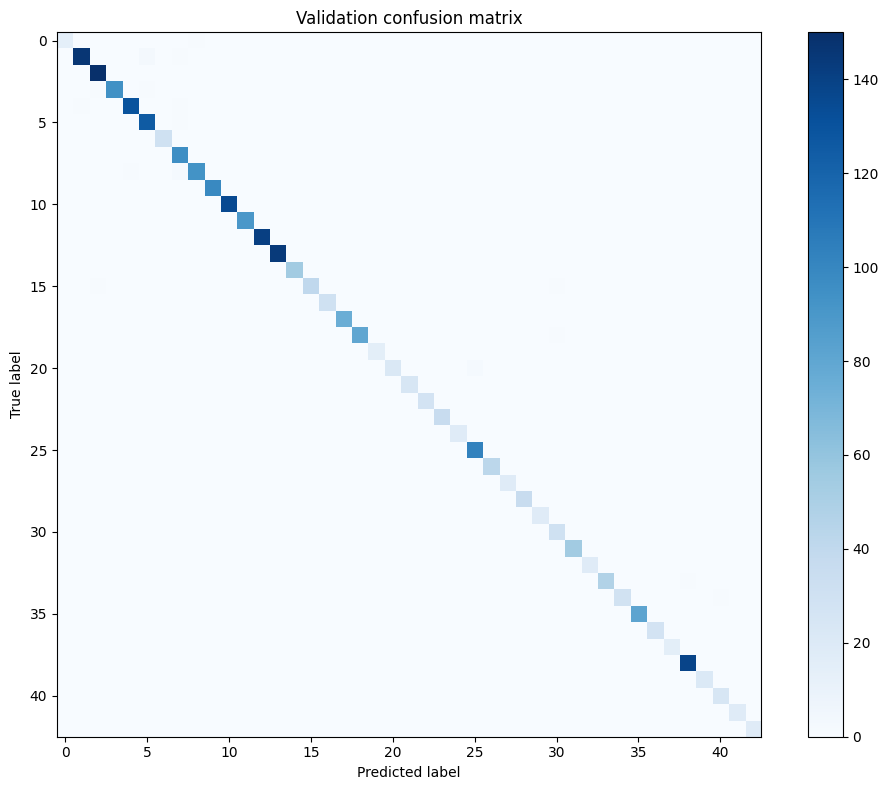

Saved: /content/traffic-sign-classification/reports/week4/baseline_confusion_matrix.png


In [23]:
cm = confusion_matrix(y_val_true, y_val_pred, labels=list(range(NUM_CLASSES)))

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Validation confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.tight_layout()

cm_path = REPORT_ROOT / "baseline_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved:", cm_path)

In [24]:
def denormalize(x, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

In [25]:
@torch.no_grad()
def collect_misclassified_samples(model, dataset, device, max_items=12):
    model.eval()
    items = []

    for idx in range(len(dataset)):
        image, label = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = int(logits.argmax(dim=1).item())

        if pred != label:
            items.append((image.cpu(), int(label), pred))
            if len(items) >= max_items:
                break

    return items

misclassified = collect_misclassified_samples(model, val_ds, DEVICE, max_items=12)
print("Collected misclassified samples:", len(misclassified))

Collected misclassified samples: 12


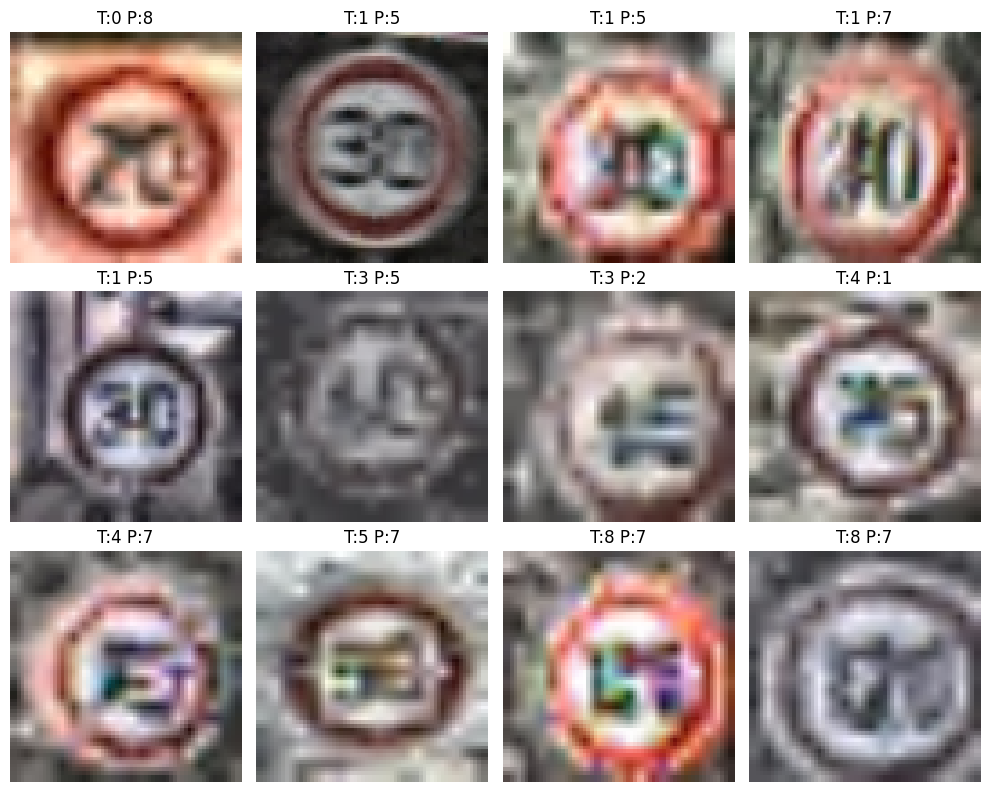

Saved: /content/traffic-sign-classification/reports/week4/baseline_misclassified_samples.png


In [26]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
axes = axes.flatten()

for ax in axes:
    ax.axis("off")

for ax, (img, true_label, pred_label) in zip(axes, misclassified):
    img = denormalize(img, MEAN, STD).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f"T:{true_label} P:{pred_label}")
    ax.axis("off")

plt.tight_layout()
mis_path = REPORT_ROOT / "baseline_misclassified_samples.png"
plt.savefig(mis_path, dpi=200)
plt.show()

print("Saved:", mis_path)

In [27]:
import pandas as pd
from torch.utils.data import DataLoader

gtsrb_root = DATA_ROOT / "gtsrb"
test_csv = gtsrb_root / "GT-final_test.csv"
test_img_dir = gtsrb_root / "GTSRB" / "Final_Test" / "Images"

test_df = pd.read_csv(test_csv, sep=";")

# Map possible ROI column name variants to the lowercase names expected by src.datasets.py
rename_map = {}
for col in test_df.columns:
    c = col.strip().lower()
    if c == "filename":
        rename_map[col] = "filename"
    elif c == "width":
        rename_map[col] = "width"
    elif c == "height":
        rename_map[col] = "height"
    elif c in ["roi.x1", "roi_x1"]:
        rename_map[col] = "roi_x1"
    elif c in ["roi.y1", "roi_y1"]:
        rename_map[col] = "roi_y1"
    elif c in ["roi.x2", "roi_x2"]:
        rename_map[col] = "roi_x2"
    elif c in ["roi.y2", "roi_y2"]:
        rename_map[col] = "roi_y2"
    elif c == "classid":
        rename_map[col] = "label"

test_df = test_df.rename(columns=rename_map)
test_df["image_path"] = test_df["filename"].apply(lambda x: str((test_img_dir / x).resolve()))
test_df["split"] = "test"

required_cols = ["image_path", "label", "roi_x1", "roi_y1", "roi_x2", "roi_y2"]
missing = [c for c in required_cols if c not in test_df.columns]
print("Missing columns:", missing)

Missing columns: []


In [28]:
test_ds = GTSRBCustomDataset(
    test_df,
    transform=eval_transform,
    use_roi_crop=USE_ROI_CROP,
    preprocessing=PREPROCESSING,
    pad_ratio=PAD_RATIO
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [29]:
test_loss, test_metrics, y_test_true, y_test_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print("Test loss:", test_loss)
print(json.dumps(test_metrics, indent=2))

  0%|          | 0/99 [00:00<?, ?it/s]

Test loss: 0.18272134886076785
{
  "accuracy": 0.9543942992874109,
  "precision_macro": 0.9288965862578114,
  "recall_macro": 0.9349601424677259,
  "f1_macro": 0.928324786957425
}


In [30]:
test_metrics_path = REPORT_ROOT / "baseline_test_metrics.json"
with open(test_metrics_path, "w") as f:
    json.dump({
        "test_loss": float(test_loss),
        "test_metrics": test_metrics
    }, f, indent=2)

print("Saved:", test_metrics_path)

Saved: /content/traffic-sign-classification/reports/week4/baseline_test_metrics.json


In [31]:
!zip -r /content/file.zip /content/traffic-sign-classification -x "/content/traffic-sign-classification/data/*"

  adding: content/traffic-sign-classification/ (stored 0%)
  adding: content/traffic-sign-classification/src/ (stored 0%)
  adding: content/traffic-sign-classification/src/datasets.py (deflated 65%)
  adding: content/traffic-sign-classification/src/__pycache__/ (stored 0%)
  adding: content/traffic-sign-classification/src/__pycache__/datasets.cpython-312.pyc (deflated 51%)
  adding: content/traffic-sign-classification/artifacts/ (stored 0%)
  adding: content/traffic-sign-classification/artifacts/metadata/ (stored 0%)
  adding: content/traffic-sign-classification/artifacts/metadata/test_metadata_full.csv (deflated 89%)
  adding: content/traffic-sign-classification/artifacts/metadata/train_metadata_full.csv (deflated 91%)
  adding: content/traffic-sign-classification/artifacts/metadata/week2_pipeline_config.json (deflated 37%)
  adding: content/traffic-sign-classification/.ipynb_checkpoints/ (stored 0%)
  adding: content/traffic-sign-classification/reports/ (stored 0%)
  adding: content/